In [2]:
import pandas as pd

ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")

# Combine
df = pd.concat([ethiopia, kenya, nigeria, sudan, tanzania], ignore_index=True)


In [3]:
df["Country"]


0        ethiopia
1        ethiopia
2        ethiopia
3        ethiopia
4        ethiopia
           ...   
20535    tanzania
20536    tanzania
20537    tanzania
20538    tanzania
20539    tanzania
Name: Country, Length: 20540, dtype: object

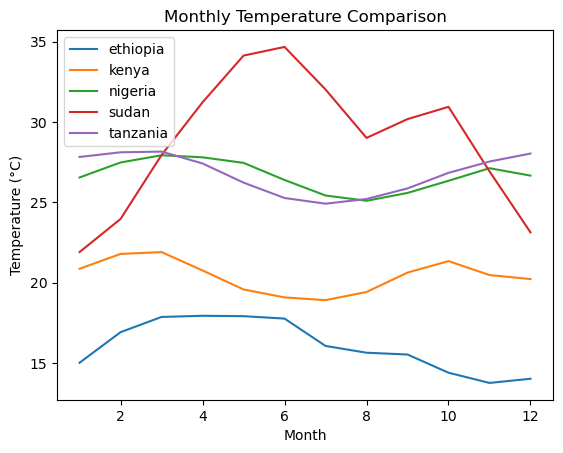

In [4]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby(["Country", "Month"])["T2M"].mean().reset_index()

for country in monthly_temp["Country"].unique():
    data = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(data["Month"], data["T2M"], label=country)

plt.legend()
plt.title("Monthly Temperature Comparison")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()


In [5]:
temp_summary = df.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary


,mean,median,std
Country,,,
ethiopia,16.068679,16.04,1.897501
kenya,20.427483,20.36,1.438281
nigeria,26.659160,26.82,1.115192
sudan,28.759607,29.16,4.679431
tanzania,26.802458,26.99,1.325279


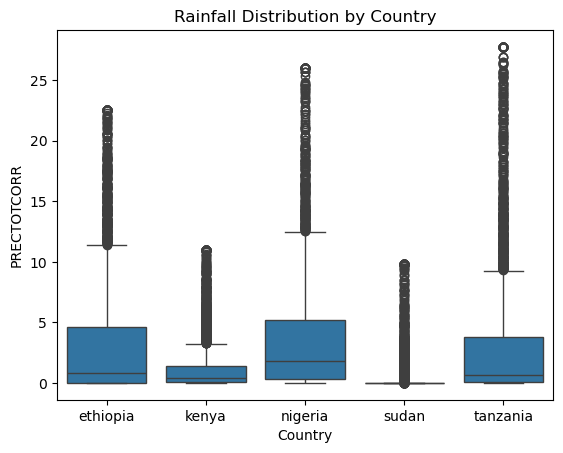

In [6]:
import seaborn as sns

sns.boxplot(x="Country", y="PRECTOTCORR", data=df)
plt.title("Rainfall Distribution by Country")
plt.show()


In [7]:
rain_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
rain_summary


,mean,median,std
Country,,,
ethiopia,3.440719,0.82,5.374903
kenya,1.323742,0.38,2.282832
nigeria,3.950704,1.84,5.454583
sudan,0.487103,0.00,1.665770
tanzania,3.420823,0.64,6.002178


In [8]:
df["Year"] = pd.to_datetime(df["Date"]).dt.year

extreme_heat = df[df["T2M_MAX"] > 35]

heat_count = extreme_heat.groupby(["Country", "Year"]).size().reset_index(name="Hot Days")


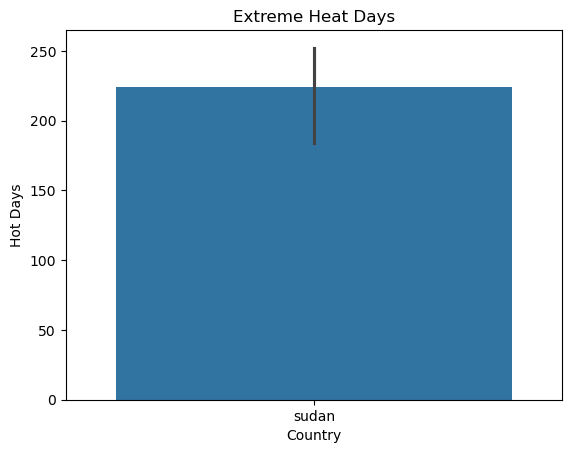

In [9]:
sns.barplot(x="Country", y="Hot Days", data=heat_count)
plt.title("Extreme Heat Days")
plt.show()


In [10]:
dry_days = df[df["PRECTOTCORR"] < 1]

dry_count = dry_days.groupby(["Country", "Year"]).size().reset_index(name="Dry Days")


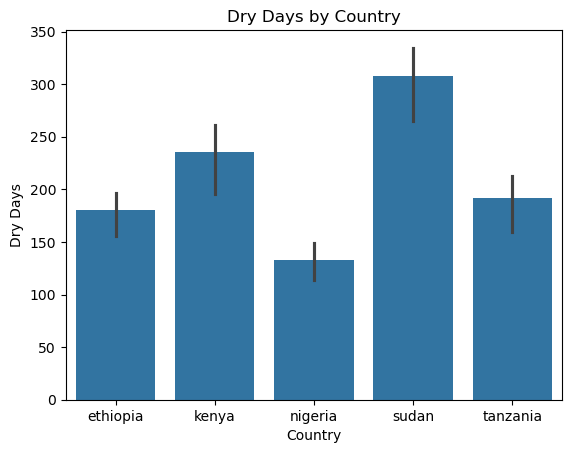

In [11]:
sns.barplot(x="Country", y="Dry Days", data=dry_count)
plt.title("Dry Days by Country")
plt.show()


In [12]:
from scipy.stats import f_oneway

groups = [df[df["Country"] == c]["T2M"].dropna() for c in df["Country"].unique()]

stat, p = f_oneway(*groups)

print("P-value:", p)


P-value: 0.0


In [13]:
ranking = pd.DataFrame({
    "Country": temp_summary.index,
    "Temp_Mean": temp_summary["mean"],
    "Rain_Std": rain_summary["std"]
}).reset_index(drop=True)

ranking


,Country,Temp_Mean,Rain_Std
0,ethiopia,16.068679,5.374903
1,kenya,20.427483,2.282832
2,nigeria,26.659160,5.454583
3,sudan,28.759607,1.665770
4,tanzania,26.802458,6.002178
